# Câu 1: Thay đổi số lượng epoch

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()  # Chuyển ảnh thành tensor
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [3]:
# 2. Định nghĩa mô hình CNN
class MNIST_CNN(nn.Module):  # Tạo lớp MNIST_CNN kế thừa từ nn.Module (lớp cơ bản của PyTorch)
    def __init__(self):  # Hàm khởi tạo mô hình
        super(MNIST_CNN, self).__init__()  # Gọi hàm khởi tạo của lớp cha (nn.Module)
        # Tầng tích chập 1: 1 kênh đầu vào (ảnh đen trắng) -> 16 kênh đầu ra, filter 3x3
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)  # Tích chập giảm kích thước từ 28x28 -> 26x26
        # Tầng tích chập 2: 16 kênh đầu vào -> 32 kênh đầu ra, filter 3x3
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # Tích chập giảm từ 12x12 -> 10x10 (sau pooling)
        # Tầng pooling: vùng 2x2, giảm kích thước một nửa
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Ví dụ: 26x26 -> 13x13, 10x10 -> 5x5
        # Tầng fully connected: từ 32 kênh * 5x5 (800) -> 10 lớp (0-9)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)  # Duỗi feature map thành vector rồi phân loại

    def forward(self, x):  # Hàm forward định nghĩa luồng dữ liệu qua các tầng
        x = self.pool(torch.relu(self.conv1(x)))  # Conv1 -> ReLU (loại giá trị âm) -> Pool (giảm kích thước)
        x = self.pool(torch.relu(self.conv2(x)))  # Conv2 -> ReLU -> Pool, cuối cùng ra 32x5x5
        x = x.view(-1, 32 * 5 * 5)  # Duỗi tensor thành vector, -1 tự động tính batch size
        x = self.fc1(x)  # Qua tầng fully connected, ra 10 giá trị (logits cho 0-9)
        return x  # Trả về kết quả dự đoán

In [4]:
# Khởi tạo mô hình
model = MNIST_CNN()  # Tạo một instance của lớp MNIST_CNN
criterion = nn.CrossEntropyLoss()  # Định nghĩa hàm mất mát CrossEntropy (dùng cho phân loại nhiều lớp)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # Dùng SGD với learning rate 0.01 và momentum 0.9 để tối ưu

In [5]:
# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

# Tạo hai danh sách để lưu giá trị mất mát (loss) và độ chính xác (accuracy) qua từng epoch
loss_values = []  # Lưu mất mát trung bình của mỗi epoch để theo dõi quá trình huấn luyện
accuracy_values = []  # Lưu độ chính xác trung bình của mỗi epoch để đánh giá hiệu quả mô hình

# Huấn luyện mô hình qua 5 epoch (mỗi epoch là một lần duyệt qua toàn bộ dữ liệu huấn luyện)
for epoch in range(10):  # Lặp 10 lần, mỗi lần xử lý toàn bộ tập dữ liệu
    # Khởi tạo biến để theo dõi tổng mất mát trong epoch này
    running_loss = 0.0  # Biến này cộng dồn mất mát của các batch để tính trung bình sau
    # Khởi tạo biến để tính độ chính xác
    correct = 0  # Đếm số dự đoán đúng trong epoch
    total = 0  # Đếm tổng số mẫu được dự đoán trong epoch
    
    # Lặp qua từng batch (nhóm 64 ảnh) trong tập huấn luyện (train_loader)
    for images, labels in train_loader:  # images: tensor chứa 64 ảnh, labels: tensor chứa 64 nhãn (0-9)
        # Chuyển ảnh và nhãn sang thiết bị (GPU/CPU) để đồng bộ với mô hình
        images, labels = images.to(device), labels.to(device)  # Đảm bảo dữ liệu và mô hình cùng thiết bị
        
        # Xóa gradient cũ từ bước trước để tránh tích lũy
        optimizer.zero_grad()  # Gradient phải được đặt về 0 trước khi tính gradient mới
        # Đưa ảnh qua mô hình để nhận dự đoán (outputs là tensor chứa logits cho 10 lớp)
        outputs = model(images)  # Mô hình xử lý ảnh và trả về dự đoán
        # Tính mất mát (loss) bằng cách so sánh dự đoán (outputs) với nhãn thật (labels)
        loss = criterion(outputs, labels)  # Hàm CrossEntropyLoss đo lường sai lệch giữa dự đoán và thực tế
        # Tính gradient ngược (backpropagation) để tìm hướng tối ưu hóa trọng số
        loss.backward()  # Gradient được tính cho tất cả tham số của mô hình
        # Cập nhật trọng số của mô hình dựa trên gradient, sử dụng thuật toán SGD
        optimizer.step()  # Điều chỉnh trọng số để giảm mất mát ở bước tiếp theo
        
        # Cộng dồn giá trị mất mát của batch này (loss.item() trả về giá trị số của loss)
        running_loss += loss.item()  # Tổng hợp mất mát để tính trung bình sau
        
        # Tính độ chính xác cho batch này
        # Lấy nhãn dự đoán bằng cách chọn lớp có giá trị logits cao nhất
        _, predicted = torch.max(outputs.data, 1)  # predicted chứa nhãn dự đoán (0-9) cho 64 ảnh
        # Cộng dồn số mẫu trong batch (thường là 64, trừ batch cuối có thể ít hơn)
        total += labels.size(0)  # Tổng số ảnh đã xử lý
        # Đếm số dự đoán đúng bằng cách so sánh predicted với labels
        correct += (predicted == labels).sum().item()  # Số dự đoán đúng trong batch
    
    # Tính mất mát trung bình cho epoch bằng cách chia tổng mất mát cho số batch
    epoch_loss = running_loss / len(train_loader)  # Trung bình mất mát của tất cả batch
    # Tính độ chính xác trung bình (phần trăm) cho epoch
    epoch_accuracy = 100 * correct / total  # Tỷ lệ dự đoán đúng trên tổng số mẫu
    # Lưu giá trị mất mát và độ chính xác để vẽ biểu đồ sau này
    loss_values.append(epoch_loss)  # Thêm mất mát trung bình vào danh sách
    accuracy_values.append(epoch_accuracy)  # Thêm độ chính xác vào danh sách
    # In kết quả sau mỗi epoch để theo dõi tiến trình huấn luyện
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")  # Hiển thị mất mát và độ chính xác

Epoch 1, Loss: 0.2654, Accuracy: 91.97%
Epoch 2, Loss: 0.0880, Accuracy: 97.28%
Epoch 3, Loss: 0.0665, Accuracy: 97.92%
Epoch 4, Loss: 0.0560, Accuracy: 98.31%
Epoch 5, Loss: 0.0505, Accuracy: 98.45%
Epoch 6, Loss: 0.0444, Accuracy: 98.61%
Epoch 7, Loss: 0.0412, Accuracy: 98.77%
Epoch 8, Loss: 0.0377, Accuracy: 98.83%
Epoch 9, Loss: 0.0329, Accuracy: 99.00%
Epoch 10, Loss: 0.0316, Accuracy: 99.02%


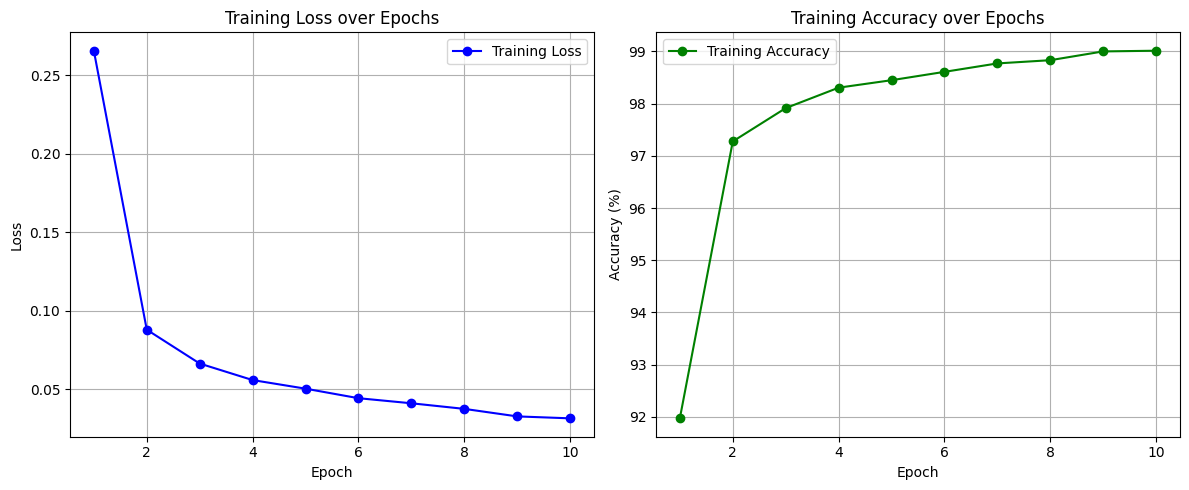

In [7]:
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), loss_values, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, 11), accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
correct = 0  # Đếm số dự đoán đúng
total = 0  # Đếm tổng số mẫu
with torch.no_grad():  # Tắt tính gradient vì chỉ đánh giá, không huấn luyện
    for images, labels in test_loader:  # Lặp qua từng batch trong tập kiểm tra
        images, labels = images.to(device), labels.to(device)  # Chuyển dữ liệu sang GPU/CPU
        outputs = model(images)  # Dự đoán trên batch ảnh
        _, predicted = torch.max(outputs.data, 1)  # Lấy chỉ số lớp có giá trị lớn nhất (dự đoán)
        total += labels.size(0)  # Cộng số mẫu trong batch vào tổng
        correct += (predicted == labels).sum().item()  # Cộng số dự đoán đúng
print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")  # Tính và in độ chính xác (%)

Độ chính xác trên tập test: 98.56%


- Độ chính xác trên tập test có thay đổi từ 98.37% sang 99.56%
- Biểu đồ hàm mất mát có xu hướng giảm dần
- Khi tăng số epoch thì mô hình sẽ dự đoán chính xác hơn

# Câu 2: Thêm một tầng tích chập

In [12]:
# 2. Định nghĩa mô hình CNN
class MNIST_CNN(nn.Module):  # Tạo lớp MNIST_CNN kế thừa từ nn.Module (lớp cơ bản của PyTorch)
    def __init__(self):  # Hàm khởi tạo mô hình
        super(MNIST_CNN, self).__init__()  # Gọi hàm khởi tạo của lớp cha (nn.Module)
        # Tầng tích chập 1: 1 kênh đầu vào (ảnh đen trắng) -> 16 kênh đầu ra, filter 3x3
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)  # Tích chập giảm kích thước từ 28x28 -> 26x26
        # Tầng tích chập 2: 16 kênh đầu vào -> 32 kênh đầu ra, filter 3x3
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # Tích chập giảm từ 12x12 -> 10x10 (sau pooling)
        # Tầng 3: 32 kênh đầu vào -> 64 kênh đầu ra, filter 3x3
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0)
        # Tầng pooling: vùng 2x2, giảm kích thước một nửa
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Ví dụ: 26x26 -> 13x13, 10x10 -> 5x5
        # Tầng fully connected: từ 32 kênh * 5x5 (800) -> 10 lớp (0-9)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)  # Duỗi feature map thành vector rồi phân loại

    def forward(self, x):  # Hàm forward định nghĩa luồng dữ liệu qua các tầng
        x = self.pool(torch.relu(self.conv1(x)))  # Conv1 -> ReLU (loại giá trị âm) -> Pool (giảm kích thước)
        x = self.pool(torch.relu(self.conv2(x)))  # Conv2 -> ReLU -> Pool, cuối cùng ra 32x5x5
        x = self.pool(torch.relu(self.conv3(x)))
        # x = x.view(-1, 32 * 5 * 5)  # Duỗi tensor thành vector, -1 tự động tính batch size
        # x = self.fc1(x)  # Qua tầng fully connected, ra 10 giá trị (logits cho 0-9)
        x = x.view(-1, 64 * 1 * 1)
        self.fc1 = nn.Linear(64 * 1 * 1, 10)
        return x  # Trả về kết quả dự đoán

In [13]:
# Khởi tạo mô hình
model = MNIST_CNN()  # Tạo một instance của lớp MNIST_CNN
criterion = nn.CrossEntropyLoss()  # Định nghĩa hàm mất mát CrossEntropy (dùng cho phân loại nhiều lớp)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # Dùng SGD với learning rate 0.01 và momentum 0.9 để tối ưu

In [14]:
# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

# Tạo hai danh sách để lưu giá trị mất mát (loss) và độ chính xác (accuracy) qua từng epoch
loss_values = []  # Lưu mất mát trung bình của mỗi epoch để theo dõi quá trình huấn luyện
accuracy_values = []  # Lưu độ chính xác trung bình của mỗi epoch để đánh giá hiệu quả mô hình

# Huấn luyện mô hình qua 5 epoch (mỗi epoch là một lần duyệt qua toàn bộ dữ liệu huấn luyện)
for epoch in range(10):  # Lặp 10 lần, mỗi lần xử lý toàn bộ tập dữ liệu
    # Khởi tạo biến để theo dõi tổng mất mát trong epoch này
    running_loss = 0.0  # Biến này cộng dồn mất mát của các batch để tính trung bình sau
    # Khởi tạo biến để tính độ chính xác
    correct = 0  # Đếm số dự đoán đúng trong epoch
    total = 0  # Đếm tổng số mẫu được dự đoán trong epoch
    
    # Lặp qua từng batch (nhóm 64 ảnh) trong tập huấn luyện (train_loader)
    for images, labels in train_loader:  # images: tensor chứa 64 ảnh, labels: tensor chứa 64 nhãn (0-9)
        # Chuyển ảnh và nhãn sang thiết bị (GPU/CPU) để đồng bộ với mô hình
        images, labels = images.to(device), labels.to(device)  # Đảm bảo dữ liệu và mô hình cùng thiết bị
        
        # Xóa gradient cũ từ bước trước để tránh tích lũy
        optimizer.zero_grad()  # Gradient phải được đặt về 0 trước khi tính gradient mới
        # Đưa ảnh qua mô hình để nhận dự đoán (outputs là tensor chứa logits cho 10 lớp)
        outputs = model(images)  # Mô hình xử lý ảnh và trả về dự đoán
        # Tính mất mát (loss) bằng cách so sánh dự đoán (outputs) với nhãn thật (labels)
        loss = criterion(outputs, labels)  # Hàm CrossEntropyLoss đo lường sai lệch giữa dự đoán và thực tế
        # Tính gradient ngược (backpropagation) để tìm hướng tối ưu hóa trọng số
        loss.backward()  # Gradient được tính cho tất cả tham số của mô hình
        # Cập nhật trọng số của mô hình dựa trên gradient, sử dụng thuật toán SGD
        optimizer.step()  # Điều chỉnh trọng số để giảm mất mát ở bước tiếp theo
        
        # Cộng dồn giá trị mất mát của batch này (loss.item() trả về giá trị số của loss)
        running_loss += loss.item()  # Tổng hợp mất mát để tính trung bình sau
        
        # Tính độ chính xác cho batch này
        # Lấy nhãn dự đoán bằng cách chọn lớp có giá trị logits cao nhất
        _, predicted = torch.max(outputs.data, 1)  # predicted chứa nhãn dự đoán (0-9) cho 64 ảnh
        # Cộng dồn số mẫu trong batch (thường là 64, trừ batch cuối có thể ít hơn)
        total += labels.size(0)  # Tổng số ảnh đã xử lý
        # Đếm số dự đoán đúng bằng cách so sánh predicted với labels
        correct += (predicted == labels).sum().item()  # Số dự đoán đúng trong batch
    
    # Tính mất mát trung bình cho epoch bằng cách chia tổng mất mát cho số batch
    epoch_loss = running_loss / len(train_loader)  # Trung bình mất mát của tất cả batch
    # Tính độ chính xác trung bình (phần trăm) cho epoch
    epoch_accuracy = 100 * correct / total  # Tỷ lệ dự đoán đúng trên tổng số mẫu
    # Lưu giá trị mất mát và độ chính xác để vẽ biểu đồ sau này
    loss_values.append(epoch_loss)  # Thêm mất mát trung bình vào danh sách
    accuracy_values.append(epoch_accuracy)  # Thêm độ chính xác vào danh sách
    # In kết quả sau mỗi epoch để theo dõi tiến trình huấn luyện
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")  # Hiển thị mất mát và độ chính xác

Epoch 1, Loss: 0.5302, Accuracy: 85.45%
Epoch 2, Loss: 0.1240, Accuracy: 96.28%
Epoch 3, Loss: 0.0986, Accuracy: 96.93%
Epoch 4, Loss: 0.0863, Accuracy: 97.36%
Epoch 5, Loss: 0.0771, Accuracy: 97.64%
Epoch 6, Loss: 0.0703, Accuracy: 97.84%
Epoch 7, Loss: 0.0651, Accuracy: 97.98%
Epoch 8, Loss: 0.0614, Accuracy: 98.06%
Epoch 9, Loss: 0.0573, Accuracy: 98.25%
Epoch 10, Loss: 0.0541, Accuracy: 98.28%


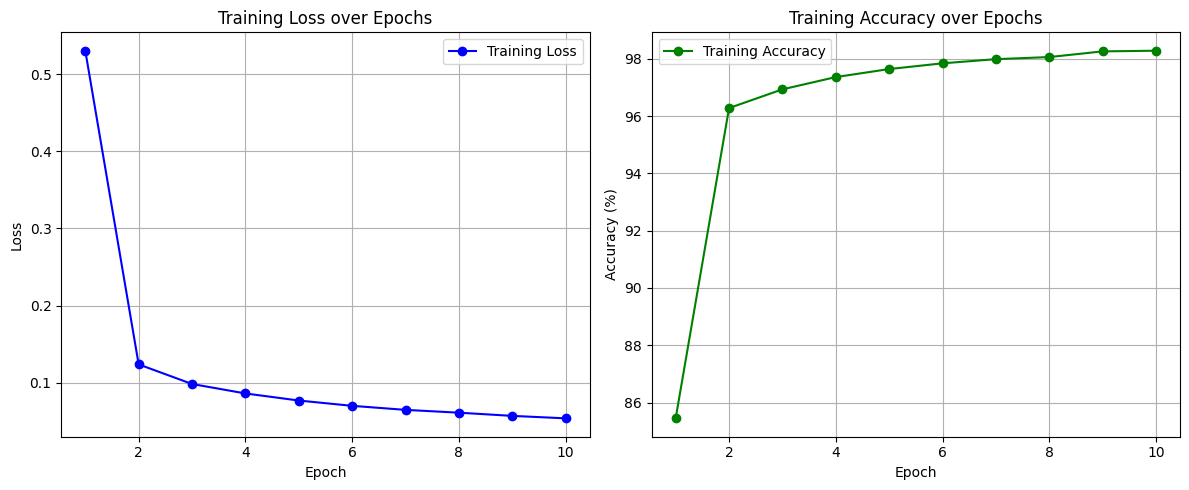

In [15]:
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), loss_values, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, 11), accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
correct = 0  # Đếm số dự đoán đúng
total = 0  # Đếm tổng số mẫu
with torch.no_grad():  # Tắt tính gradient vì chỉ đánh giá, không huấn luyện
    for images, labels in test_loader:  # Lặp qua từng batch trong tập kiểm tra
        images, labels = images.to(device), labels.to(device)  # Chuyển dữ liệu sang GPU/CPU
        outputs = model(images)  # Dự đoán trên batch ảnh
        _, predicted = torch.max(outputs.data, 1)  # Lấy chỉ số lớp có giá trị lớn nhất (dự đoán)
        total += labels.size(0)  # Cộng số mẫu trong batch vào tổng
        correct += (predicted == labels).sum().item()  # Cộng số dự đoán đúng
print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")  # Tính và in độ chính xác (%)

Độ chính xác trên tập test: 98.11%


Thêm một tầng tích chập (CNN) có những tác dụng chính:

- Bắt được đặc trưng phức tạp hơn: tầng sâu hơn học được các mẫu trừu tượng hơn (ví dụ từ cạnh → hình dạng → phần của đối tượng).  
- Mở rộng trường nhìn nhận (receptive field): mỗi neuron ở tầng sau nhìn thấy vùng ảnh lớn hơn, giúp nắm bối cảnh rộng hơn.  
- Cải thiện khả năng phân biệt: tăng độ sâu thường nâng cao hiệu suất phân loại/nhận dạng nếu có đủ dữ liệu và regularization.  


# Câu 3: Thay đổi learning rate

In [21]:
# Khởi tạo mô hình
model = MNIST_CNN()  # Tạo một instance của lớp MNIST_CNN
criterion = nn.CrossEntropyLoss()  # Định nghĩa hàm mất mát CrossEntropy (dùng cho phân loại nhiều lớp)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)  # Dùng SGD với learning rate 0.01 và momentum 0.9 để tối ưu

In [22]:
# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

# Tạo hai danh sách để lưu giá trị mất mát (loss) và độ chính xác (accuracy) qua từng epoch
loss_values = []  # Lưu mất mát trung bình của mỗi epoch để theo dõi quá trình huấn luyện
accuracy_values = []  # Lưu độ chính xác trung bình của mỗi epoch để đánh giá hiệu quả mô hình

# Huấn luyện mô hình qua 5 epoch (mỗi epoch là một lần duyệt qua toàn bộ dữ liệu huấn luyện)
for epoch in range(5):  # Lặp 5 lần, mỗi lần xử lý toàn bộ tập dữ liệu
    # Khởi tạo biến để theo dõi tổng mất mát trong epoch này
    running_loss = 0.0  # Biến này cộng dồn mất mát của các batch để tính trung bình sau
    # Khởi tạo biến để tính độ chính xác
    correct = 0  # Đếm số dự đoán đúng trong epoch
    total = 0  # Đếm tổng số mẫu được dự đoán trong epoch
    
    # Lặp qua từng batch (nhóm 64 ảnh) trong tập huấn luyện (train_loader)
    for images, labels in train_loader:  # images: tensor chứa 64 ảnh, labels: tensor chứa 64 nhãn (0-9)
        # Chuyển ảnh và nhãn sang thiết bị (GPU/CPU) để đồng bộ với mô hình
        images, labels = images.to(device), labels.to(device)  # Đảm bảo dữ liệu và mô hình cùng thiết bị
        
        # Xóa gradient cũ từ bước trước để tránh tích lũy
        optimizer.zero_grad()  # Gradient phải được đặt về 0 trước khi tính gradient mới
        # Đưa ảnh qua mô hình để nhận dự đoán (outputs là tensor chứa logits cho 10 lớp)
        outputs = model(images)  # Mô hình xử lý ảnh và trả về dự đoán
        # Tính mất mát (loss) bằng cách so sánh dự đoán (outputs) với nhãn thật (labels)
        loss = criterion(outputs, labels)  # Hàm CrossEntropyLoss đo lường sai lệch giữa dự đoán và thực tế
        # Tính gradient ngược (backpropagation) để tìm hướng tối ưu hóa trọng số
        loss.backward()  # Gradient được tính cho tất cả tham số của mô hình
        # Cập nhật trọng số của mô hình dựa trên gradient, sử dụng thuật toán SGD
        optimizer.step()  # Điều chỉnh trọng số để giảm mất mát ở bước tiếp theo
        
        # Cộng dồn giá trị mất mát của batch này (loss.item() trả về giá trị số của loss)
        running_loss += loss.item()  # Tổng hợp mất mát để tính trung bình sau
        
        # Tính độ chính xác cho batch này
        # Lấy nhãn dự đoán bằng cách chọn lớp có giá trị logits cao nhất
        _, predicted = torch.max(outputs.data, 1)  # predicted chứa nhãn dự đoán (0-9) cho 64 ảnh
        # Cộng dồn số mẫu trong batch (thường là 64, trừ batch cuối có thể ít hơn)
        total += labels.size(0)  # Tổng số ảnh đã xử lý
        # Đếm số dự đoán đúng bằng cách so sánh predicted với labels
        correct += (predicted == labels).sum().item()  # Số dự đoán đúng trong batch
    
    # Tính mất mát trung bình cho epoch bằng cách chia tổng mất mát cho số batch
    epoch_loss = running_loss / len(train_loader)  # Trung bình mất mát của tất cả batch
    # Tính độ chính xác trung bình (phần trăm) cho epoch
    epoch_accuracy = 100 * correct / total  # Tỷ lệ dự đoán đúng trên tổng số mẫu
    # Lưu giá trị mất mát và độ chính xác để vẽ biểu đồ sau này
    loss_values.append(epoch_loss)  # Thêm mất mát trung bình vào danh sách
    accuracy_values.append(epoch_accuracy)  # Thêm độ chính xác vào danh sách
    # In kết quả sau mỗi epoch để theo dõi tiến trình huấn luyện
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")  # Hiển thị mất mát và độ chính xác

Epoch 1, Loss: 2.9656, Accuracy: 36.81%
Epoch 2, Loss: 1.0428, Accuracy: 76.75%
Epoch 3, Loss: 0.7917, Accuracy: 81.80%
Epoch 4, Loss: 0.7143, Accuracy: 83.47%
Epoch 5, Loss: 0.6748, Accuracy: 84.44%


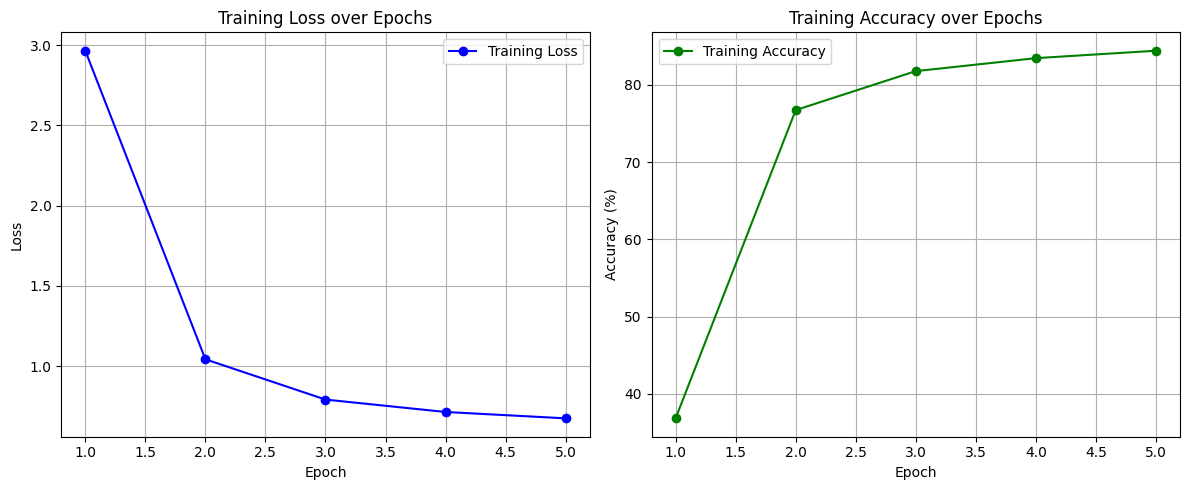

In [23]:
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, 6), loss_values, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, 6), accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
correct = 0  # Đếm số dự đoán đúng
total = 0  # Đếm tổng số mẫu
with torch.no_grad():  # Tắt tính gradient vì chỉ đánh giá, không huấn luyện
    for images, labels in test_loader:  # Lặp qua từng batch trong tập kiểm tra
        images, labels = images.to(device), labels.to(device)  # Chuyển dữ liệu sang GPU/CPU
        outputs = model(images)  # Dự đoán trên batch ảnh
        _, predicted = torch.max(outputs.data, 1)  # Lấy chỉ số lớp có giá trị lớn nhất (dự đoán)
        total += labels.size(0)  # Cộng số mẫu trong batch vào tổng
        correct += (predicted == labels).sum().item()  # Cộng số dự đoán đúng
print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")  # Tính và in độ chính xác (%)

Độ chính xác trên tập test: 85.00%


---

In [25]:
# Khởi tạo mô hình
model = MNIST_CNN()  # Tạo một instance của lớp MNIST_CNN
criterion = nn.CrossEntropyLoss()  # Định nghĩa hàm mất mát CrossEntropy (dùng cho phân loại nhiều lớp)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)  # Dùng SGD với learning rate 0.01 và momentum 0.9 để tối ưu

In [26]:
# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

# Tạo hai danh sách để lưu giá trị mất mát (loss) và độ chính xác (accuracy) qua từng epoch
loss_values = []  # Lưu mất mát trung bình của mỗi epoch để theo dõi quá trình huấn luyện
accuracy_values = []  # Lưu độ chính xác trung bình của mỗi epoch để đánh giá hiệu quả mô hình

# Huấn luyện mô hình qua 5 epoch (mỗi epoch là một lần duyệt qua toàn bộ dữ liệu huấn luyện)
for epoch in range(5):  # Lặp 5 lần, mỗi lần xử lý toàn bộ tập dữ liệu
    # Khởi tạo biến để theo dõi tổng mất mát trong epoch này
    running_loss = 0.0  # Biến này cộng dồn mất mát của các batch để tính trung bình sau
    # Khởi tạo biến để tính độ chính xác
    correct = 0  # Đếm số dự đoán đúng trong epoch
    total = 0  # Đếm tổng số mẫu được dự đoán trong epoch
    
    # Lặp qua từng batch (nhóm 64 ảnh) trong tập huấn luyện (train_loader)
    for images, labels in train_loader:  # images: tensor chứa 64 ảnh, labels: tensor chứa 64 nhãn (0-9)
        # Chuyển ảnh và nhãn sang thiết bị (GPU/CPU) để đồng bộ với mô hình
        images, labels = images.to(device), labels.to(device)  # Đảm bảo dữ liệu và mô hình cùng thiết bị
        
        # Xóa gradient cũ từ bước trước để tránh tích lũy
        optimizer.zero_grad()  # Gradient phải được đặt về 0 trước khi tính gradient mới
        # Đưa ảnh qua mô hình để nhận dự đoán (outputs là tensor chứa logits cho 10 lớp)
        outputs = model(images)  # Mô hình xử lý ảnh và trả về dự đoán
        # Tính mất mát (loss) bằng cách so sánh dự đoán (outputs) với nhãn thật (labels)
        loss = criterion(outputs, labels)  # Hàm CrossEntropyLoss đo lường sai lệch giữa dự đoán và thực tế
        # Tính gradient ngược (backpropagation) để tìm hướng tối ưu hóa trọng số
        loss.backward()  # Gradient được tính cho tất cả tham số của mô hình
        # Cập nhật trọng số của mô hình dựa trên gradient, sử dụng thuật toán SGD
        optimizer.step()  # Điều chỉnh trọng số để giảm mất mát ở bước tiếp theo
        
        # Cộng dồn giá trị mất mát của batch này (loss.item() trả về giá trị số của loss)
        running_loss += loss.item()  # Tổng hợp mất mát để tính trung bình sau
        
        # Tính độ chính xác cho batch này
        # Lấy nhãn dự đoán bằng cách chọn lớp có giá trị logits cao nhất
        _, predicted = torch.max(outputs.data, 1)  # predicted chứa nhãn dự đoán (0-9) cho 64 ảnh
        # Cộng dồn số mẫu trong batch (thường là 64, trừ batch cuối có thể ít hơn)
        total += labels.size(0)  # Tổng số ảnh đã xử lý
        # Đếm số dự đoán đúng bằng cách so sánh predicted với labels
        correct += (predicted == labels).sum().item()  # Số dự đoán đúng trong batch
    
    # Tính mất mát trung bình cho epoch bằng cách chia tổng mất mát cho số batch
    epoch_loss = running_loss / len(train_loader)  # Trung bình mất mát của tất cả batch
    # Tính độ chính xác trung bình (phần trăm) cho epoch
    epoch_accuracy = 100 * correct / total  # Tỷ lệ dự đoán đúng trên tổng số mẫu
    # Lưu giá trị mất mát và độ chính xác để vẽ biểu đồ sau này
    loss_values.append(epoch_loss)  # Thêm mất mát trung bình vào danh sách
    accuracy_values.append(epoch_accuracy)  # Thêm độ chính xác vào danh sách
    # In kết quả sau mỗi epoch để theo dõi tiến trình huấn luyện
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")  # Hiển thị mất mát và độ chính xác

Epoch 1, Loss: 0.3422, Accuracy: 90.31%
Epoch 2, Loss: 0.1104, Accuracy: 96.62%
Epoch 3, Loss: 0.0927, Accuracy: 97.16%
Epoch 4, Loss: 0.0825, Accuracy: 97.53%
Epoch 5, Loss: 0.0851, Accuracy: 97.42%


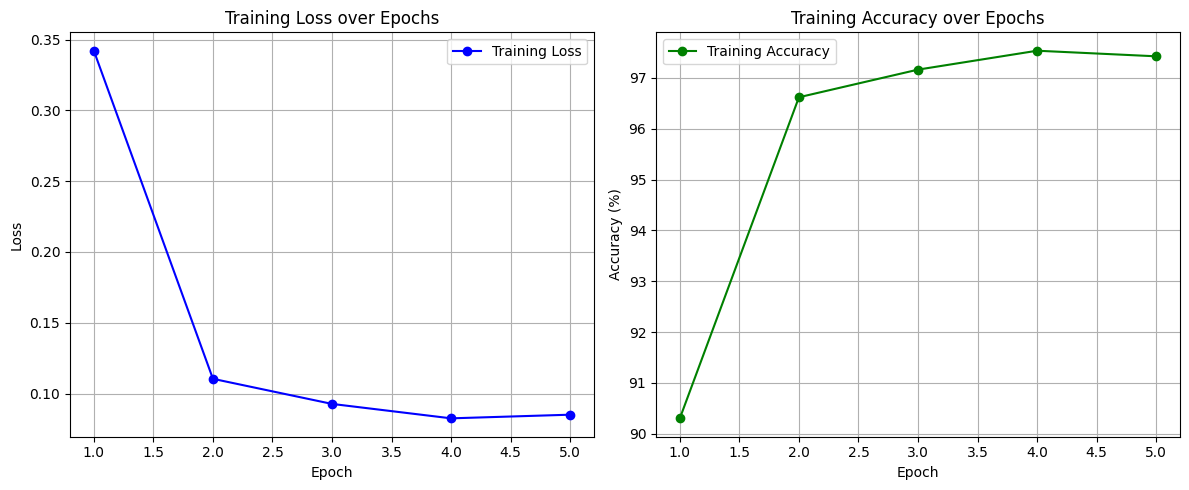

In [27]:
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, 6), loss_values, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, 6), accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
correct = 0  # Đếm số dự đoán đúng
total = 0  # Đếm tổng số mẫu
with torch.no_grad():  # Tắt tính gradient vì chỉ đánh giá, không huấn luyện
    for images, labels in test_loader:  # Lặp qua từng batch trong tập kiểm tra
        images, labels = images.to(device), labels.to(device)  # Chuyển dữ liệu sang GPU/CPU
        outputs = model(images)  # Dự đoán trên batch ảnh
        _, predicted = torch.max(outputs.data, 1)  # Lấy chỉ số lớp có giá trị lớn nhất (dự đoán)
        total += labels.size(0)  # Cộng số mẫu trong batch vào tổng
        correct += (predicted == labels).sum().item()  # Cộng số dự đoán đúng
print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")  # Tính và in độ chính xác (%)

Độ chính xác trên tập test: 96.66%


- Với learning rate 0.001 -> độ chính xác 85%, biểu đồ giao động chậm
- Với learning rate 0.1 -> độ chính xác 96.66%, biểu đồ giao động mạnh
- Nếu learning rate nhỏ thì cần phải tăng số epoch để tăng độ chính xác

# Câu 4: Vẽ thêm feature map từ tầng tích chập thứ 2

In [36]:
# 2. Định nghĩa mô hình CNN
class MNIST_CNN(nn.Module):  # Tạo lớp MNIST_CNN kế thừa từ nn.Module (lớp cơ bản của PyTorch)
    def __init__(self):  # Hàm khởi tạo mô hình
        super(MNIST_CNN, self).__init__()  # Gọi hàm khởi tạo của lớp cha (nn.Module)
        # Tầng tích chập 1: 1 kênh đầu vào (ảnh đen trắng) -> 16 kênh đầu ra, filter 3x3
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)  # Tích chập giảm kích thước từ 28x28 -> 26x26
        # Tầng tích chập 2: 16 kênh đầu vào -> 32 kênh đầu ra, filter 3x3
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # Tích chập giảm từ 12x12 -> 10x10 (sau pooling)
        # Tầng pooling: vùng 2x2, giảm kích thước một nửa
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Ví dụ: 26x26 -> 13x13, 10x10 -> 5x5
        # Tầng fully connected: từ 32 kênh * 5x5 (800) -> 10 lớp (0-9)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)  # Duỗi feature map thành vector rồi phân loại

    def forward(self, x):  # Hàm forward định nghĩa luồng dữ liệu qua các tầng
        x = self.pool(torch.relu(self.conv1(x)))  # Conv1 -> ReLU (loại giá trị âm) -> Pool (giảm kích thước)
        x = self.pool(torch.relu(self.conv2(x)))  # Conv2 -> ReLU -> Pool, cuối cùng ra 32x5x5
        x = x.view(-1, 32 * 5 * 5)  # Duỗi tensor thành vector, -1 tự động tính batch size
        x = self.fc1(x)  # Qua tầng fully connected, ra 10 giá trị (logits cho 0-9)
        return x  # Trả về kết quả dự đoán

# Khởi tạo mô hình
model = MNIST_CNN()  # Tạo một instance của lớp MNIST_CNN
criterion = nn.CrossEntropyLoss()  # Định nghĩa hàm mất mát CrossEntropy (dùng cho phân loại nhiều lớp)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # Dùng SGD với learning rate 0.01 và momentum 0.9 để tối ưu

# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

# Tạo hai danh sách để lưu giá trị mất mát (loss) và độ chính xác (accuracy) qua từng epoch
loss_values = []  # Lưu mất mát trung bình của mỗi epoch để theo dõi quá trình huấn luyện
accuracy_values = []  # Lưu độ chính xác trung bình của mỗi epoch để đánh giá hiệu quả mô hình

# Huấn luyện mô hình qua 5 epoch (mỗi epoch là một lần duyệt qua toàn bộ dữ liệu huấn luyện)
for epoch in range(5):  # Lặp 5 lần, mỗi lần xử lý toàn bộ tập dữ liệu
    # Khởi tạo biến để theo dõi tổng mất mát trong epoch này
    running_loss = 0.0  # Biến này cộng dồn mất mát của các batch để tính trung bình sau
    # Khởi tạo biến để tính độ chính xác
    correct = 0  # Đếm số dự đoán đúng trong epoch
    total = 0  # Đếm tổng số mẫu được dự đoán trong epoch
    
    # Lặp qua từng batch (nhóm 64 ảnh) trong tập huấn luyện (train_loader)
    for images, labels in train_loader:  # images: tensor chứa 64 ảnh, labels: tensor chứa 64 nhãn (0-9)
        # Chuyển ảnh và nhãn sang thiết bị (GPU/CPU) để đồng bộ với mô hình
        images, labels = images.to(device), labels.to(device)  # Đảm bảo dữ liệu và mô hình cùng thiết bị
        
        # Xóa gradient cũ từ bước trước để tránh tích lũy
        optimizer.zero_grad()  # Gradient phải được đặt về 0 trước khi tính gradient mới
        # Đưa ảnh qua mô hình để nhận dự đoán (outputs là tensor chứa logits cho 10 lớp)
        outputs = model(images)  # Mô hình xử lý ảnh và trả về dự đoán
        # Tính mất mát (loss) bằng cách so sánh dự đoán (outputs) với nhãn thật (labels)
        loss = criterion(outputs, labels)  # Hàm CrossEntropyLoss đo lường sai lệch giữa dự đoán và thực tế
        # Tính gradient ngược (backpropagation) để tìm hướng tối ưu hóa trọng số
        loss.backward()  # Gradient được tính cho tất cả tham số của mô hình
        # Cập nhật trọng số của mô hình dựa trên gradient, sử dụng thuật toán SGD
        optimizer.step()  # Điều chỉnh trọng số để giảm mất mát ở bước tiếp theo
        
        # Cộng dồn giá trị mất mát của batch này (loss.item() trả về giá trị số của loss)
        running_loss += loss.item()  # Tổng hợp mất mát để tính trung bình sau
        
        # Tính độ chính xác cho batch này
        # Lấy nhãn dự đoán bằng cách chọn lớp có giá trị logits cao nhất
        _, predicted = torch.max(outputs.data, 1)  # predicted chứa nhãn dự đoán (0-9) cho 64 ảnh
        # Cộng dồn số mẫu trong batch (thường là 64, trừ batch cuối có thể ít hơn)
        total += labels.size(0)  # Tổng số ảnh đã xử lý
        # Đếm số dự đoán đúng bằng cách so sánh predicted với labels
        correct += (predicted == labels).sum().item()  # Số dự đoán đúng trong batch
    
    # Tính mất mát trung bình cho epoch bằng cách chia tổng mất mát cho số batch
    epoch_loss = running_loss / len(train_loader)  # Trung bình mất mát của tất cả batch
    # Tính độ chính xác trung bình (phần trăm) cho epoch
    epoch_accuracy = 100 * correct / total  # Tỷ lệ dự đoán đúng trên tổng số mẫu
    # Lưu giá trị mất mát và độ chính xác để vẽ biểu đồ sau này
    loss_values.append(epoch_loss)  # Thêm mất mát trung bình vào danh sách
    accuracy_values.append(epoch_accuracy)  # Thêm độ chính xác vào danh sách
    # In kết quả sau mỗi epoch để theo dõi tiến trình huấn luyện
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")  # Hiển thị mất mát và độ chính xác

Epoch 1, Loss: 0.2626, Accuracy: 92.27%
Epoch 2, Loss: 0.0816, Accuracy: 97.57%
Epoch 3, Loss: 0.0614, Accuracy: 98.14%
Epoch 4, Loss: 0.0520, Accuracy: 98.45%
Epoch 5, Loss: 0.0459, Accuracy: 98.58%


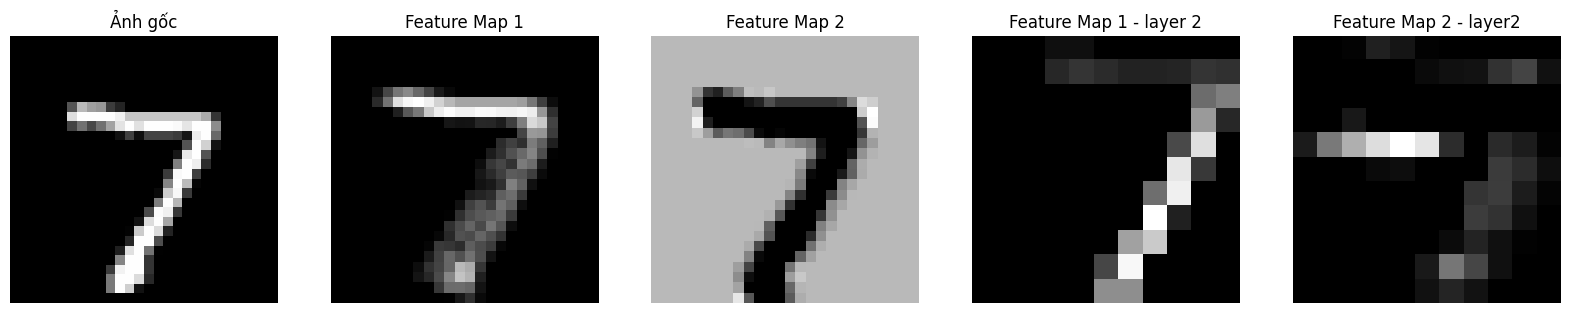

In [38]:
#Trực quan feature map
def visualize_feature_map():  # Hàm để vẽ ảnh gốc và feature map từ tầng conv1
    model.eval()  # Chuyển sang chế độ đánh giá
    images, _ = next(iter(test_loader))  # Lấy một batch từ tập kiểm tra (bỏ nhãn)
    img = images[0].unsqueeze(0).to(device)  # Lấy ảnh đầu tiên, thêm chiều batch (1x1x28x28)
    
    # Tính feature map từ conv1
    conv1_output = torch.relu(model.conv1(img))  # Qua conv1 và ReLU, ra tensor 1x16x26x26
    conv2_output = torch.relu(model.conv2(model.pool(torch.relu(model.conv1(img)))))
    
    # Vẽ ảnh gốc và feature map
    plt.figure(figsize=(20, 4))  
    plt.subplot(1, 5, 1)  
    plt.title("Ảnh gốc")  
    plt.imshow(img.cpu().squeeze(), cmap='gray') 
    plt.axis('off')  
    
    # Vẽ feature map đầu tiên
    plt.subplot(1, 5, 2)  
    plt.title("Feature Map 1")  
    plt.imshow(conv1_output[0, 0].cpu().detach().numpy(), cmap='gray')  
    plt.axis('off')  
    
    # Vẽ feature map thứ hai
    plt.subplot(1, 5, 3)  
    plt.title("Feature Map 2") 
    plt.imshow(conv1_output[0, 1].cpu().detach().numpy(), cmap='gray')  
    plt.axis('off') 
    
    plt.subplot(1, 5, 4)  
    plt.title("Feature Map 1 - layer 2")  
    plt.imshow(conv2_output[0, 0].cpu().detach().numpy(), cmap='gray')  
    plt.axis('off')  
    
    plt.subplot(1, 5, 5)  
    plt.title("Feature Map 2 - layer2") 
    plt.imshow(conv2_output[0, 1].cpu().detach().numpy(), cmap='gray')  
    plt.axis('off') 
    plt.show() 

visualize_feature_map()  